✅ Total images found: 670


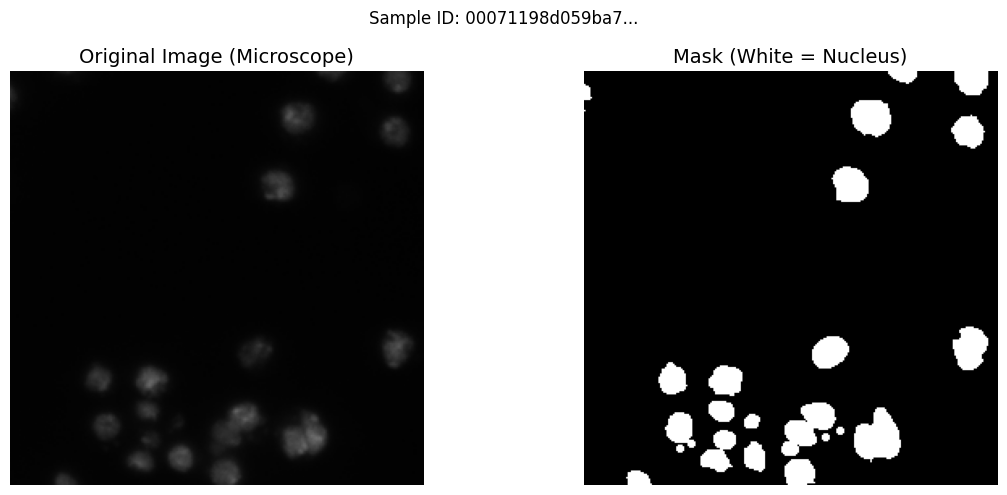

In [1]:
#Stage 01- Sahinul

import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from PIL import Image

# ✅ Point this to where you extracted the Kaggle dataset
TRAIN_PATH = '../images/stage1_train/'

# Get all image folder IDs
image_ids = os.listdir(TRAIN_PATH)
print(f"✅ Total images found: {len(image_ids)}")

# Pick one image to look at
sample_id = image_ids[0]

# Load the image
img_path = os.path.join(TRAIN_PATH, sample_id, 'images', os.listdir(
    os.path.join(TRAIN_PATH, sample_id, 'images'))[0])
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load its mask (the "answer" — where nuclei are)
mask_folder = os.path.join(TRAIN_PATH, sample_id, 'masks')
masks = []
for mask_file in os.listdir(mask_folder):
    mask = cv2.imread(os.path.join(mask_folder, mask_file), 0)
    masks.append(mask)

# Combine all individual masks into one
combined_mask = np.zeros_like(masks[0])
for m in masks:
    combined_mask = np.maximum(combined_mask, m)

# Show the image and its mask side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title('Original Image (Microscope)', fontsize=14)
axes[0].axis('off')

axes[1].imshow(combined_mask, cmap='gray')
axes[1].set_title('Mask (White = Nucleus)', fontsize=14)
axes[1].axis('off')

plt.suptitle(f'Sample ID: {sample_id[:15]}...', fontsize=12)
plt.tight_layout()
plt.show()

In [2]:
#Stage 02-Sahinul

from tqdm import tqdm  # shows a loading bar

# Settings
IMG_HEIGHT = 128
IMG_WIDTH  = 128
IMG_CHANNELS = 3

# We'll use only first 10 images (as per your project requirement)
NUM_IMAGES = 10
image_ids_subset = image_ids[:NUM_IMAGES]

# Empty arrays to store data
X = np.zeros((NUM_IMAGES, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.uint8)
Y = np.zeros((NUM_IMAGES, IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.bool_)

print("📦 Loading and resizing images...")

for i, img_id in enumerate(tqdm(image_ids_subset)):

    # --- Load Image ---
    img_folder = os.path.join(TRAIN_PATH, img_id, 'images')
    img_file   = os.listdir(img_folder)[0]
    img        = cv2.imread(os.path.join(img_folder, img_file))
    img        = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img        = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    X[i]       = img

    # --- Load + Combine Masks ---
    mask_folder = os.path.join(TRAIN_PATH, img_id, 'masks')
    combined    = np.zeros((IMG_HEIGHT, IMG_WIDTH, 1), dtype=np.bool_)

    for mask_file in os.listdir(mask_folder):
        mask_path = os.path.join(mask_folder, mask_file)
        mask      = cv2.imread(mask_path, 0)
        mask      = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
        mask      = np.expand_dims(mask, axis=-1)
        combined  = np.maximum(combined, mask)

    Y[i] = combined

print(f"\n✅ Done!")
print(f"   X shape (images): {X.shape}")   # (10, 128, 128, 3)
print(f"   Y shape (masks):  {Y.shape}")    # (10, 128, 128, 1)

📦 Loading and resizing images...


100%|██████████| 10/10 [00:00<00:00, 30.24it/s]


✅ Done!
   X shape (images): (10, 128, 128, 3)
   Y shape (masks):  (10, 128, 128, 1)
